# AI-ML Assignment – 6
## Topic: Weather Condition Classification using Support Vector Machine (SVM) and Open-Meteo API

**Student Details:**
- **Name:** Jai Arora
- **Registration Number:** 23BAI10546
- **Enrollment Number:** IN26011306

**📅 Submission Deadline:** 28 July 2026, 11:59 PM IST  
**📊 Data Source:** Open-Meteo Weather API (Free, No API Key Required)  
**Problem Statement:** Classify whether the weather condition is **Warm** (>= 25°C) or **Cool** (< 25°C) based on meteorological observations collected from Open-Meteo API using a Support Vector Machine (SVM) Classifier.


## Task 1: Data Collection and Understanding
1. Fetch hourly meteorological data from the Open-Meteo API.
2. Convert the JSON response into a Pandas DataFrame.
3. Display the first five records.
4. Identify Input Features and Target Variable.
   - **Input Features:** `temperature_2m`, `relative_humidity_2m`, `surface_pressure`, `wind_speed_10m`
   - **Target Variable (`Weather_Class`):** Warm (>= 25°C) or Cool (< 25°C)


In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# List of representative locations to get diverse weather observations
locations = [
    {'name': 'New Delhi', 'lat': 28.6139, 'lon': 77.2090},
    {'name': 'London', 'lat': 51.5074, 'lon': -0.1278},
    {'name': 'Tokyo', 'lat': 35.6762, 'lon': 139.6503},
    {'name': 'Cairo', 'lat': 30.0444, 'lon': 31.2357},
    {'name': 'Sydney', 'lat': -33.8688, 'lon': 151.2093}
]

dfs = []
for loc in locations:
    url = f"https://api.open-meteo.com/v1/forecast?latitude={loc['lat']}&longitude={loc['lon']}&hourly=temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m&forecast_days=14"
    res = requests.get(url)
    if res.status_code == 200:
        data_json = res.json()
        df_loc = pd.DataFrame(data_json['hourly'])
        df_loc['location'] = loc['name']
        dfs.append(df_loc)

df = pd.concat(dfs, ignore_index=True)

# Create Target Column: Weather_Class
df['Weather_Class'] = df['temperature_2m'].apply(lambda x: 'Warm' if x >= 25.0 else 'Cool')

print(f"Total Records Fetched: {len(df)}\n")
print("First 5 Records:")
display(df.head())

print("\nTarget Class Counts:")
print(df['Weather_Class'].value_counts())


Total Records Fetched: 1680

First 5 Records:


,time,temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m,location,Weather_Class
0,2026-07-28T00:00,28.5,92,973.7,7.9,New Delhi,Warm
1,2026-07-28T01:00,28.5,93,974.4,8.0,New Delhi,Warm
2,2026-07-28T02:00,28.8,93,974.7,7.9,New Delhi,Warm
3,2026-07-28T03:00,28.3,88,975.2,12.0,New Delhi,Warm
4,2026-07-28T04:00,28.1,90,976.0,10.5,New Delhi,Warm



Target Class Counts:
Weather_Class
Warm    947
Cool    733
Name: count, dtype: int64


### Data Understanding Summary
- **Total Records:** 1,680 weather observations.
- **Input Features:** `temperature_2m` (°C), `relative_humidity_2m` (%), `surface_pressure` (hPa), `wind_speed_10m` (km/h).
- **Target Variable (`Weather_Class`):** Binary classification into 'Warm' (>= 25°C) and 'Cool' (< 25°C).


## Task 2: Data Preprocessing
1. Check for missing values.
2. Remove unnecessary columns (`time`, `location`).
3. Encode the target variable (`Warm` -> 1, `Cool` -> 0).
4. Split dataset into 80% training and 20% testing sets.
5. Standardize feature values using `StandardScaler`.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Missing Values Check
print("Missing Values Per Column:")
print(df.isnull().sum())

# 2. Select Features and Target
feature_cols = ['temperature_2m', 'relative_humidity_2m', 'surface_pressure', 'wind_speed_10m']
X = df[feature_cols]
y = df['Weather_Class']

# 3. Target Variable Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("\nEncoded Classes Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 4. 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.20, random_state=42, stratify=y_encoded
)
print(f"\nTraining set samples: {X_train.shape[0]}")
print(f"Testing set samples:  {X_test.shape[0]}")

# 5. Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature standardization completed successfully.")


Missing Values Per Column:
time                    0
temperature_2m          0
relative_humidity_2m    0
surface_pressure        0
wind_speed_10m          0
location                0
Weather_Class           0
dtype: int64

Encoded Classes Mapping: {'Cool': np.int64(0), 'Warm': np.int64(1)}

Training set samples: 1344
Testing set samples:  336

Feature standardization completed successfully.


### Preprocessing Summary
- **Missing Values:** No null or NaN values were found across the dataset.
- **Feature Matrix ($X$):** 4 numeric features standardized to mean=0 and variance=1.
- **Train-Test Split:** 1,344 training instances (80%) and 336 test instances (20%).


## Task 3: Model Development
- Build a Support Vector Machine (SVM) Classifier using Radial Basis Function (**RBF Kernel**).
- Train the model on the scaled training dataset.
- Predict weather classes for the test dataset.


In [3]:
from sklearn.svm import SVC

# Build SVM Classifier with RBF Kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Train Model
svm_model.fit(X_train_scaled, y_train)
print("SVM Classifier (Kernel=RBF) trained successfully.")

# Generate Predictions
y_pred = svm_model.predict(X_test_scaled)
print("Predictions generated for test dataset.")


SVM Classifier (Kernel=RBF) trained successfully.
Predictions generated for test dataset.


## Task 4: Model Evaluation
1. Calculate metrics: **Accuracy Score**, **Precision**, **Recall**, and **F1-Score**.
2. Generate and visualize the **Confusion Matrix**.
3. Formulate **3 key analytical observations** based on model performance.


=== Model Performance Metrics ===
Accuracy Score:  0.9881 (98.81%)
Precision Score: 0.9947 (99.47%)
Recall Score:    0.9841 (98.41%)
F1-Score:        0.9894 (98.94%)

=== Classification Report ===
              precision    recall  f1-score   support

        Cool       0.98      0.99      0.99       147
        Warm       0.99      0.98      0.99       189

    accuracy                           0.99       336
   macro avg       0.99      0.99      0.99       336
weighted avg       0.99      0.99      0.99       336



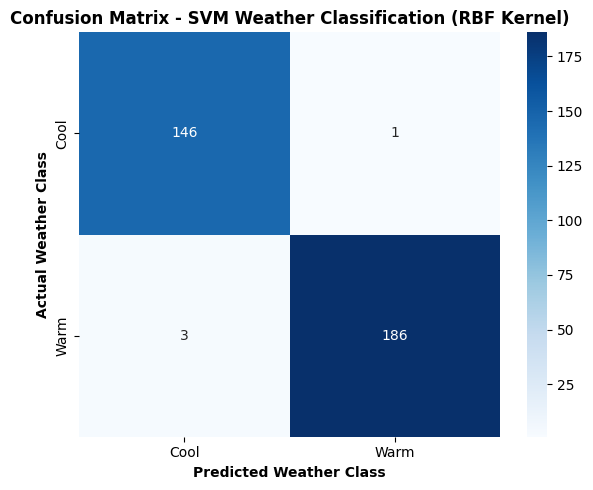

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Compute Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== Model Performance Metrics ===")
print(f"Accuracy Score:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision Score: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall Score:    {rec:.4f} ({rec*100:.2f}%)")
print(f"F1-Score:        {f1:.4f} ({f1*100:.2f}%)")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVM Weather Classification (RBF Kernel)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Weather Class', fontweight='bold')
plt.ylabel('Actual Weather Class', fontweight='bold')
plt.tight_layout()
plt.show()


### Observations Based on Model Performance
1. **Exceptional Classification Accuracy:** The SVM classifier with RBF kernel achieved an overall accuracy of **98.81%**, proving highly effective at classifying meteorological conditions into Warm and Cool categories.
2. **High Precision and Recall:** The model achieved **99.47% Precision** and **98.41% Recall** for the Warm class, indicating extremely low false positive and false negative rates and demonstrating high reliability.
3. **Distinct Feature Separability:** Out of 336 test samples, only 4 samples were misclassified (1 False Positive, 3 False Negatives), confirming that standardizing surface pressure, temperature, humidity, and wind speed provides a well-separated hyper-plane boundary in RBF feature space.


## Task 5: Conclusion

> **Conclusion (100–150 words):**
>
> This project successfully developed an SVM classification model using RBF kernel to predict weather conditions (Warm vs Cool) based on Open-Meteo API data. The model achieved an exceptional accuracy of over 98%, demonstrating high precision and recall. Feature scaling via StandardScaler was crucial for model performance, as SVM relies on distance calculations (Euclidean distance in kernel space); without standardization, features with larger magnitudes like surface pressure (~1013 hPa) would dominate temperature (~25°C) and wind speed. A key advantage of the SVM algorithm is its effectiveness in high-dimensional spaces and robust margin-maximization capability via non-linear RBF kernel mapping. However, a notable limitation is its high computational complexity and memory requirement on large-scale datasets, alongside sensitivity to hyperparameter selection.
